In [28]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pylab as plt

import seaborn as sns

from skspatial.objects import Line, Plane
from skspatial.plotting import plot_3d

from skspatial.objects import Line, Cylinder, Point, Points
from skspatial.plotting import plot_3d

import phasespace

import tensorflow

import os

import bisect
import numpy as np
import matplotlib.pylab as plt
import pandas as pd

import seaborn as sns

import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal

import numpy as np
from scipy.interpolate import griddata
from scipy.integrate import quad, trapezoid
from scipy.interpolate import CubicSpline

import matplotlib.pylab as plt
from scipy import stats
from matplotlib import cm
from matplotlib.ticker import LinearLocator

from scipy.interpolate import LinearNDInterpolator

import eloss_tools


import dm_generation_tools as dgt
import detector_simulation_tools as dst
import diagnostics as dg

import earthshine_io as eio
import diagnostics_v2 as diag


import glob

import time

####################################
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")


import pickle

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
#infile = 'OUTPUT_FILES/generated_data_depth_-8.0--4000.0_diskR_4000.0_mDM_1000.0-9000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED.parquet'
infile = 'OUTPUT_FILES/generated_data_depth_-8.0--4000.0_diskR_4000.0_mDM_10000.0-90000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED.parquet'

df = pd.read_parquet(infile)

df

,M_DM,M_A,px1,py1,pz1,e1,px2,py2,pz2,e2,...,ip_inner_z0,ip_inner_x1,ip_inner_y1,ip_inner_z1,distance_to_detector,efinal_mu1,pt1_detector_acceptance,pt1_detector_acceptance_eloss,org_nevents,total_org_nevents
185587,10000.0,0.22,225.775403,5668.907214,-140.190109,5675.133198,172.041705,4320.123687,-106.786820,4324.866524,...,NaN,NaN,NaN,NaN,241.270530,4156.702120,5673.401408,4155.433686,1000000,2000000000
238387,10000.0,0.22,-1499.285948,3903.618548,2156.108769,4704.774294,-1687.444406,4393.494195,2426.761751,5295.227330,...,NaN,NaN,NaN,NaN,3508.403352,-567.882012,4181.637971,-504.737706,1000000,2000000000
319530,10000.0,0.22,-1431.865449,1593.219046,5496.399921,5899.067528,-995.442980,1107.601550,3820.989809,4100.932949,...,NaN,NaN,NaN,NaN,2495.572680,-284.833898,2142.098409,-103.430286,1000000,2000000000
382823,10000.0,0.22,-3160.303248,3512.582817,587.896325,4761.446919,-3476.939982,3864.567477,646.861420,5238.551626,...,NaN,NaN,NaN,NaN,621.136283,2028.932518,4725.013721,2013.407721,1000000,2000000000
388434,10000.0,0.22,-2999.572751,3023.673513,1550.377286,4532.516734,-3618.320080,3647.368948,1870.250793,5467.483743,...,NaN,NaN,NaN,NaN,4868.643824,-649.903204,4259.112373,-610.700620,1000000,2000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8223732,90000.0,0.22,-23836.446961,37685.501477,9951.341208,45688.099294,-23118.264229,36550.125569,9651.576620,44311.609668,...,NaN,NaN,NaN,NaN,3427.383852,101.095615,44591.178783,98.668422,1000000,2000000000
8338866,90000.0,0.22,43501.863969,29136.374025,12292.014872,53781.354481,29295.146249,19621.054658,8277.736546,36217.568968,...,NaN,NaN,NaN,NaN,4133.417086,-294.527755,52357.811835,-286.731878,1000000,2000000000
8561480,90000.0,0.22,3833.668369,35598.176913,33382.080797,48951.920606,3214.653108,29850.161260,27991.974825,41047.737776,...,NaN,NaN,NaN,NaN,3086.284785,577.851313,35804.011126,422.647254,1000000,2000000000
8721035,90000.0,0.22,2325.441807,22710.967473,41038.756126,46961.422759,2131.206712,20813.774540,37610.413189,43038.336781,...,NaN,NaN,NaN,NaN,4444.582745,-449.738255,22829.711412,-218.634657,1000000,2000000000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178695 entries, 185587 to 8979272
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   M_DM                           178695 non-null  float64
 1   M_A                            178695 non-null  float64
 2   px1                            178695 non-null  float64
 3   py1                            178695 non-null  float64
 4   pz1                            178695 non-null  float64
 5   e1                             178695 non-null  float64
 6   px2                            178695 non-null  float64
 7   py2                            178695 non-null  float64
 8   pz2                            178695 non-null  float64
 9   e2                             178695 non-null  float64
 10  pmag1                          178695 non-null  float64
 11  pt1                            178695 non-null  float64
 12  eta1                         

In [31]:
mass = 1000
filter = (df['M_DM'] == mass)

len(df[filter])

0

In [32]:
def get_df_of_acceptances(df, energycut=[100]):
    masses = df['M_DM'].unique()
    masses
    
    org_nevents = df['total_org_nevents'].iloc[0]
    print(org_nevents, org_nevents/1e6)

    dftot = None
    for idx,ecut in enumerate(energycut):
        # Require the muons to reach CMS with some given energy
        filter = (df['efinal_mu1']>ecut)

        # Require them to hit the inner detector
        filter_hit_id = df['hit_inner_detector']==True

        #########################################################################
        vcounts = df[filter]['M_DM'].value_counts()
        dftmp = vcounts.to_frame()
        dftmp = dftmp.reset_index(names='M_DM')
        dftmp = dftmp.rename(columns={'count':f'count_ecut{ecut}'})
        
        dftmp['org_nevents'] = org_nevents
        dftmp[f'frac_ecut{ecut}'] = dftmp[f'count_ecut{ecut}']/org_nevents

        #########################################################################
        vcounts = df[filter & filter_hit_id]['M_DM'].value_counts()
        dftmp2 = vcounts.to_frame()
        dftmp2 = dftmp2.reset_index(names='M_DM')
        dftmp2 = dftmp2.rename(columns={'count':f'count_hit_id_ecut{ecut}'})
        
        dftmp2['org_nevents'] = org_nevents
        dftmp2[f'frac_hit_id_ecut{ecut}'] = dftmp2[f'count_hit_id_ecut{ecut}']/org_nevents

        
        print(ecut)

        if idx==0:
            dftot = dftmp.copy()
            dftot = pd.merge(dftot, dftmp2, on=['M_DM', 'org_nevents'], how='outer')

        else:
            #dftot = pd.concat([dftmp, dftot], join='outer', ignore_index=True)
            dftot = pd.merge(dftot, dftmp, on=['M_DM', 'org_nevents'], how='outer')
            dftot = pd.merge(dftot, dftmp2, on=['M_DM', 'org_nevents'], how='outer')
            
    
    #dftmp.columns
    #dftmp.index
    
    #dftmp.values
    #dftmp
    return dftot

In [33]:
#generated_data_depth_-8.0--4000.0_diskR_4000.0_mDM_1000.0-9000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED.parquet

#model = 'dmModel_momentum'
model = 'dmModel_floating'
vol = 'depth_-8.0--4000.0_diskR_4000.0'
volume = (4000-8)*(np.pi*(4000**2))

'''
vol = 'depth_-8.0--4000.0_diskR_40.0'
volume = (4000-8)*(np.pi*(40**2))
model = 'dmModel_core'
'''

print(f'volume: {volume} m^3')
print(f'volume: {volume/1e9} km^3')


eloss = 'ave_eloss'

my_dir = './OUTPUT_FILES/'
infiles = glob.glob(my_dir + f"/*{vol}*{model}*{eloss}*COMBINED.parquet")

#infiles = glob

dfs = []
for infile in infiles:
    
    print(infile)
    df = pd.read_parquet(infile)

    dftmp = get_df_of_acceptances(df, energycut=[10, 100, 1000])

    dfs.append(dftmp)

dfs

dfacc = pd.concat(dfs)
dfacc = dfacc.sort_values(by='M_DM')

dfacc['volume m3'] = volume 

dfacc

volume: 200659805970.08725 m^3
volume: 200.65980597008726 km^3
./OUTPUT_FILES/generated_data_depth_-8.0--4000.0_diskR_4000.0_mDM_10000.0-90000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED.parquet
2000000000 2000.0
10
100
1000
./OUTPUT_FILES/generated_data_depth_-8.0--4000.0_diskR_4000.0_mDM_100000.0-900000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED.parquet
2000000000 2000.0
10
100
1000
./OUTPUT_FILES/generated_data_depth_-8.0--4000.0_diskR_4000.0_mDM_1000.0-9000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED.parquet
2000000000 2000.0
10
100
1000


,M_DM,count_ecut10,org_nevents,frac_ecut10,count_hit_id_ecut10,frac_hit_id_ecut10,count_ecut100,frac_ecut100,count_hit_id_ecut100,frac_hit_id_ecut100,count_ecut1000,frac_ecut1000,count_hit_id_ecut1000,frac_hit_id_ecut1000,volume m3
0,1000.0,2182,2000000000,0.000001,42,2.100000e-08,1652,8.260000e-07,35,1.750000e-08,NaN,NaN,NaN,NaN,2.006598e+11
1,2000.0,3595,2000000000,0.000002,81,4.050000e-08,3080,1.540000e-06,69,3.450000e-08,145.0,7.250000e-08,2.0,1.000000e-09,2.006598e+11
2,3000.0,4519,2000000000,0.000002,102,5.100000e-08,3967,1.983500e-06,80,4.000000e-08,911.0,4.555000e-07,19.0,9.500000e-09,2.006598e+11
3,4000.0,5327,2000000000,0.000003,136,6.800000e-08,4792,2.396000e-06,121,6.050000e-08,1769.0,8.845000e-07,56.0,2.800000e-08,2.006598e+11
4,5000.0,6018,2000000000,0.000003,105,5.250000e-08,5538,2.769000e-06,95,4.750000e-08,2410.0,1.205000e-06,45.0,2.250000e-08,2.006598e+11
5,6000.0,6619,2000000000,0.000003,119,5.950000e-08,6127,3.063500e-06,108,5.400000e-08,2935.0,1.467500e-06,55.0,2.750000e-08,2.006598e+11
6,7000.0,6909,2000000000,0.000003,129,6.450000e-08,6458,3.229000e-06,117,5.850000e-08,3354.0,1.677000e-06,60.0,3.000000e-08,2.006598e+11
7,8000.0,7362,2000000000,0.000004,150,7.500000e-08,6881,3.440500e-06,138,6.900000e-08,3848.0,1.924000e-06,82.0,4.100000e-08,2.006598e+11
8,9000.0,7615,2000000000,0.000004,172,8.600000e-08,7160,3.580000e-06,164,8.200000e-08,4221.0,2.110500e-06,86.0,4.300000e-08,2.006598e+11
0,10000.0,8101,2000000000,0.000004,192,9.600000e-08,7639,3.819500e-06,186,9.300000e-08,4639.0,2.319500e-06,114.0,5.700000e-08,2.006598e+11


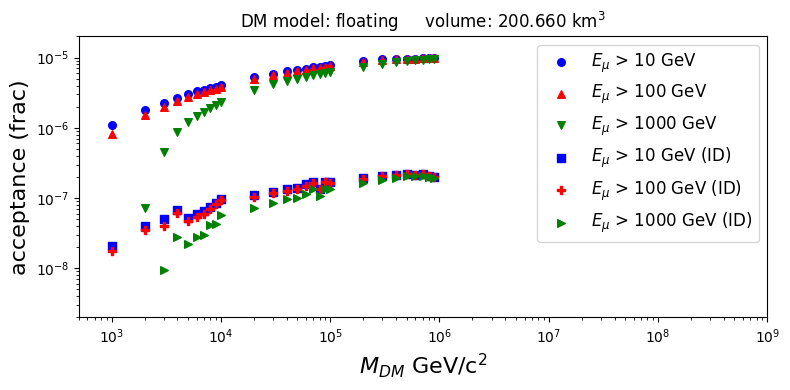

In [34]:
#model = 'dmModel_floating'
#model = 'dmModel_momentum'
#model = 'dmModel_floating'
#model = 'dmModel_core'

label_tag = ''
ylim = (0,1)
if model == 'dmModel_core':
    label_tag = 'core'
    ylim = (1e-4,0.2)
elif model == 'dmModel_floating':
    label_tag = 'floating'
    ylim = (2e-9,2e-5)
elif model == 'dmModel_momentum':
    label_tag = 'mono-energetic'
    ylim = (2e-9,2e-5)

plt.figure(figsize=(8,4))
dfacc.plot(x='M_DM', y='frac_ecut10', kind='scatter', ax=plt.gca(), color='b', marker='o', s=30,  label=r'$E_{\mu}$ > 10 GeV')
dfacc.plot(x='M_DM', y='frac_ecut100', kind='scatter', ax=plt.gca(), color='r', marker='^',s=30, label='$E_{\mu}$ > 100 GeV')
dfacc.plot(x='M_DM', y='frac_ecut1000', kind='scatter', ax=plt.gca(), color='g', marker='v',s=30, label='$E_{\mu}$ > 1000 GeV')

dfacc.plot(x='M_DM', y='frac_hit_id_ecut10', kind='scatter', ax=plt.gca(), color='b', marker='s', s=30,  label=r'$E_{\mu}$ > 10 GeV (ID)')
dfacc.plot(x='M_DM', y='frac_hit_id_ecut100', kind='scatter', ax=plt.gca(), color='r', marker='P',s=30, label='$E_{\mu}$ > 100 GeV (ID)')
dfacc.plot(x='M_DM', y='frac_hit_id_ecut1000', kind='scatter', ax=plt.gca(), color='g', marker='>',s=30, label='$E_{\mu}$ > 1000 GeV (ID)')


plt.title(f'DM model: {label_tag}     volume: {volume/1e9:.3f} km$^3$')
plt.xscale('log')
plt.xlabel('$M_{DM}$ GeV/c$^2$', fontsize=16)
#plt.ylabel('# $\mu$ strike detector / # $mu$', fontsize=16)
plt.ylabel('acceptance (frac)', fontsize=16)
plt.ylim(ylim[0], ylim[1])

plt.xlim(5e2, 1e9)

plt.legend(fontsize=12)
plt.yscale('log')
plt.tight_layout()

filename = f'acc_dm_model_{label_tag}.png'
plt.savefig(filename)

filename = f'acc_dm_model_{label_tag}.parquet'
dfacc.to_parquet(filename)

# Checking efficiences for different parameter settings

In [52]:
cat = eio.read_catalog("data")

depth = -108.0

df, params = eio.load_many(cat, dm_model="momentum_constrained", stage="combined",
                      depth_min=depth, depth_max=depth, \
                     mDM_min=10000, mDM_max=10000, eloss='ave')   # add filters until exactly 1 matches

norg = df['total_org_nevents'].iloc[0]
filter = df['hit_inner_detector']==True
n = len(df[filter])

print(f'depth: {depth}   # org: {norg}    n: {n}      n/# org: {n/norg:.2e}      100*n/# org (%): {100*n/norg:.2e}  ')

depth: -108.0   # org: 5000000000    n: 1526      n/# org: 3.05e-07      100*n/# org (%): 3.05e-05  


<Axes: xlabel='distance_to_detector', ylabel='Count'>

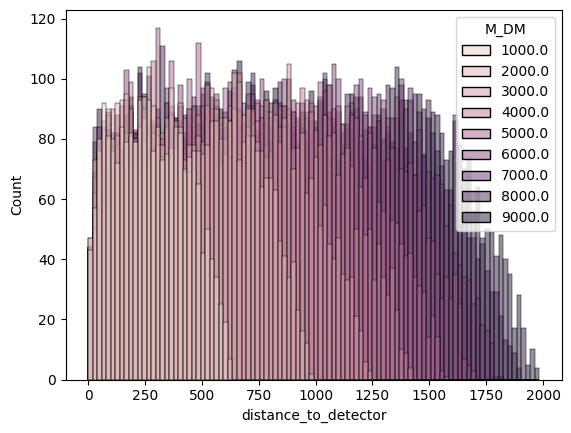

In [26]:
filter = (df['efinal_mu1']>10)


sns.histplot(df[filter], x='distance_to_detector', bins=100, hue='M_DM')


<Axes: xlabel='y0', ylabel='Count'>

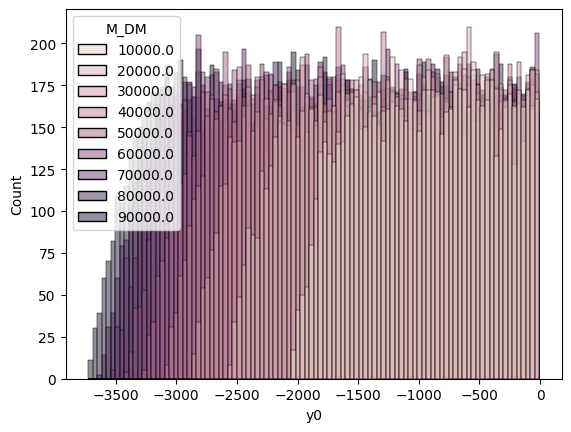

In [9]:
filter = (df['efinal_mu1']>10)

sns.histplot(df[filter], x='y0', bins=100, hue='M_DM')


<Axes: xlabel='y0', ylabel='Count'>

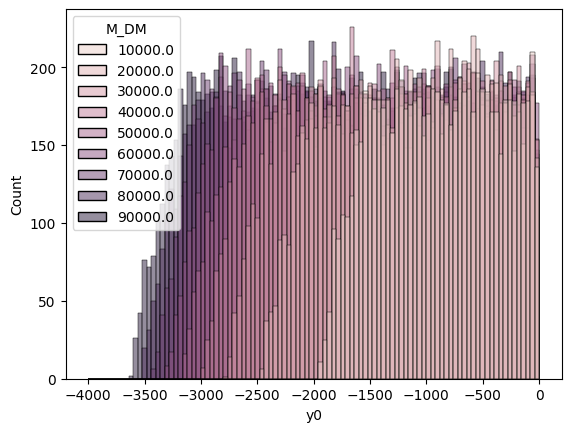

In [10]:
filter = (df['efinal_mu1']>100)

sns.histplot(df[filter], x='y0', bins=100, hue='M_DM', binrange=(-4000,0))


<Axes: >

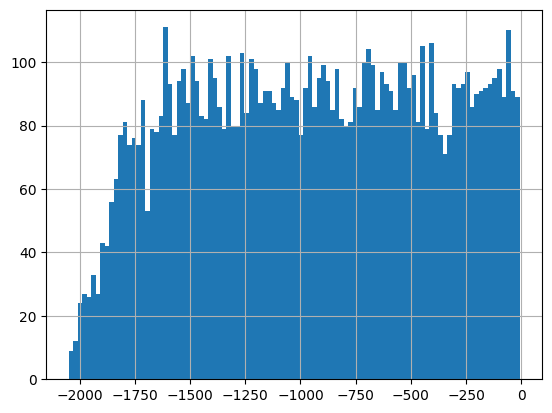

In [11]:
filter = (df['M_DM']==10000) & (df['efinal_mu1']>10)

df[filter]['y0'].hist(bins=100)